In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_df = pd.read_csv("D:\\Applied_Machine_learning\\titanic\\train.csv")
test_df  = pd.read_csv("D:\\Applied_Machine_learning\\titanic\\test.csv")

In [3]:
print("Shape:", train_df.shape)
display(train_df.head(3))




Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
# count for nan
na_counts = train_df.isna().sum().sort_values(ascending=False)
display(na_counts.head(20))


Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [5]:
# data types
display(train_df.dtypes.value_counts())


int64      5
object     5
float64    2
Name: count, dtype: int64

In [6]:
TARGET = "Survived"

y = train_df[TARGET].astype(int)
X = train_df.drop(columns=[TARGET])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = test_df.copy()   # no Survived column

In [7]:
# Feature engineering
for col in ["Name", "Ticket"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_val   = X_val.drop(columns=[col])
        X_test  = X_test.drop(columns=[col])

# create new features for cabin because cabin column has a lot of NAN
if "Cabin" in X_train.columns:
    for D in [X_train, X_val, X_test]:
        D["HasCabin"] = D["Cabin"].notna().astype(int)
        D["CabinDeck"] = D["Cabin"].str[0]
    X_train = X_train.drop(columns=["Cabin"])
    X_val   = X_val.drop(columns=["Cabin"])
    X_test  = X_test.drop(columns=["Cabin"])


In [8]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_and_plot(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, digits=4))  # Precision/Recall/F1

    plt.figure(figsize=(4.6, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc, cm


In [10]:
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {title}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return roc_auc



BernoulliNB alpha=1.0
Accuracy: 0.7654
Confusion Matrix:
 [[85 25]
 [17 52]]
              precision    recall  f1-score   support

           0     0.8333    0.7727    0.8019       110
           1     0.6753    0.7536    0.7123        69

    accuracy                         0.7654       179
   macro avg     0.7543    0.7632    0.7571       179
weighted avg     0.7724    0.7654    0.7674       179



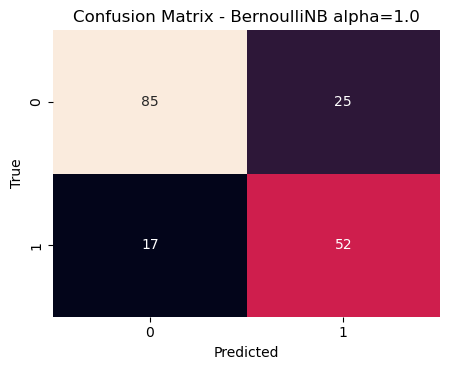

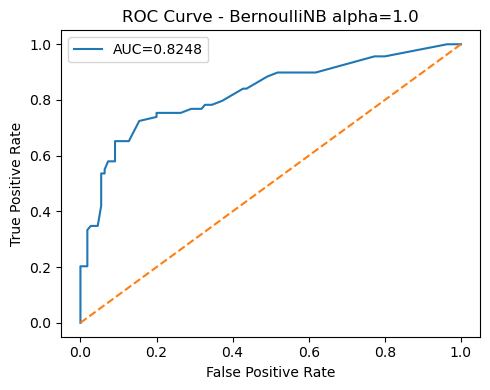


BernoulliNB alpha=0.01
Accuracy: 0.7598
Confusion Matrix:
 [[84 26]
 [17 52]]
              precision    recall  f1-score   support

           0     0.8317    0.7636    0.7962       110
           1     0.6667    0.7536    0.7075        69

    accuracy                         0.7598       179
   macro avg     0.7492    0.7586    0.7518       179
weighted avg     0.7681    0.7598    0.7620       179



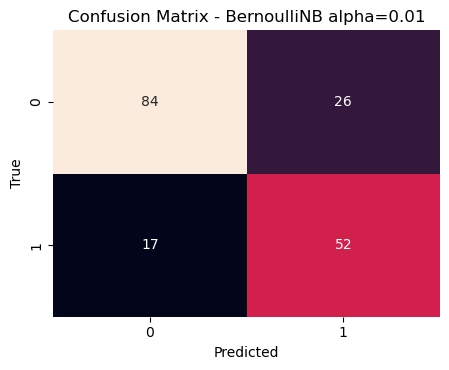

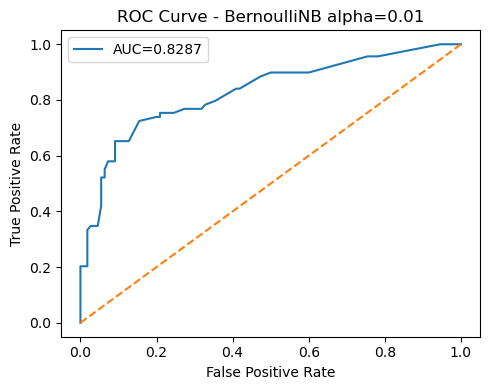


BernoulliNB alpha=1e-10
Accuracy: 0.7598
Confusion Matrix:
 [[84 26]
 [17 52]]
              precision    recall  f1-score   support

           0     0.8317    0.7636    0.7962       110
           1     0.6667    0.7536    0.7075        69

    accuracy                         0.7598       179
   macro avg     0.7492    0.7586    0.7518       179
weighted avg     0.7681    0.7598    0.7620       179



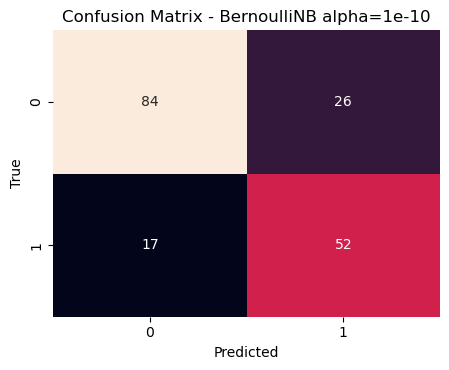

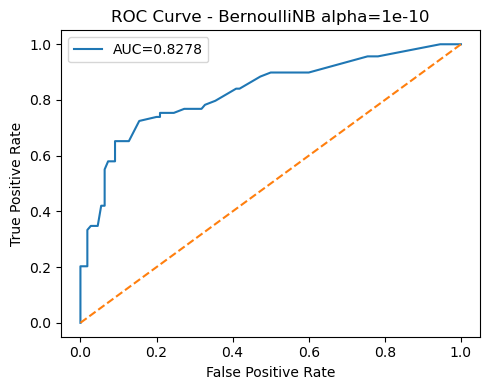

In [11]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.base import clone

# Naive Bayes implementations
numeric_pipe_nb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("minmax", MinMaxScaler())
])
categorical_pipe_nb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess_nb = ColumnTransformer(
    [("num", numeric_pipe_nb, num_cols),
     ("cat", categorical_pipe_nb, cat_cols)]
)

def eval_nb(alpha):
    model = Pipeline(steps=[
        ("prep", clone(preprocess_nb)),
        ("nb", BernoulliNB(alpha=alpha, binarize=0.5))
    ])
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model, proba, pred

alphas = [1.0, 0.01, 1e-10]

# 1e-10 is close to zero, which means no smooting.
nb_outputs = {}
for a in alphas:
    nb_model, nb_proba, nb_pred = eval_nb(a)
    nb_outputs[a] = (nb_proba, nb_pred)

    evaluate_and_plot(y_val, nb_pred, f"BernoulliNB alpha={a}")
    plot_roc(y_val, nb_proba, f"BernoulliNB alpha={a}")

In [12]:
# Linear regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_lr = ColumnTransformer(transformers=[
    ("num", numeric_preprocess, num_cols),
    ("cat", categorical_preprocess, cat_cols)
])


def predict_as_class(reg_pipeline, X, threshold=0.5):
    """
    Convert regression outputs to binary class labels using a threshold.
    """
    score = reg_pipeline.predict(X)          # continuous output
    score = np.clip(score, 0, 1)             # make it probability-like
    pred = (score >= threshold).astype(int)  # 0/1 prediction
    return score, pred


In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_binary(y_true, y_pred, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, digits=4))

    return acc, cm




In [14]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone

def fit_and_eval_regressor(regressor, name):
    """
    Fit a regression model and evaluate it as a binary classifier (threshold=0.5).
    """
    model = Pipeline(steps=[
        ("prep", clone(preprocess_lr)),
        ("reg", regressor)
    ])

    model.fit(X_train, y_train)

    val_score, val_pred = predict_as_class(model, X_val, threshold=0.5)
    acc, cm = evaluate_binary(y_val, val_pred, name=name)

    return model, val_score, val_pred, acc, cm

In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
#run linear regression with different regularizations

lr_model,   lr_score,   lr_pred,   lr_acc,   lr_cm   = fit_and_eval_regressor(
    LinearRegression(), "LinearRegression (thr=0.5)"
)

ridge_model, ridge_score, ridge_pred, ridge_acc, ridge_cm = fit_and_eval_regressor(
    Ridge(alpha=1.0), "Ridge alpha=1.0 (thr=0.5)"
)

lasso_model, lasso_score, lasso_pred, lasso_acc, lasso_cm = fit_and_eval_regressor(
    Lasso(alpha=0.001, max_iter=10000), "Lasso alpha=0.001 (thr=0.5)"
)



LinearRegression (thr=0.5)
Accuracy: 0.7989
Confusion Matrix:
 [[97 13]
 [23 46]]
              precision    recall  f1-score   support

           0     0.8083    0.8818    0.8435       110
           1     0.7797    0.6667    0.7188        69

    accuracy                         0.7989       179
   macro avg     0.7940    0.7742    0.7811       179
weighted avg     0.7973    0.7989    0.7954       179


Ridge alpha=1.0 (thr=0.5)
Accuracy: 0.8045
Confusion Matrix:
 [[98 12]
 [23 46]]
              precision    recall  f1-score   support

           0     0.8099    0.8909    0.8485       110
           1     0.7931    0.6667    0.7244        69

    accuracy                         0.8045       179
   macro avg     0.8015    0.7788    0.7864       179
weighted avg     0.8034    0.8045    0.8007       179


Lasso alpha=0.001 (thr=0.5)
Accuracy: 0.8156
Confusion Matrix:
 [[98 12]
 [21 48]]
              precision    recall  f1-score   support

           0     0.8235    0.8909    0.855